In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import localSettings as ls
import math
print(ls.main_path)
import load_data_run123
import plotter_alex
import importlib
importlib.reload(plotter_alex)
import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import pickle
import xgboost as xgb
import nue_booster 
importlib.reload(nue_booster)
import awkward
from matplotlib import gridspec
from collections import defaultdict

/home/alex/NuMI/PELEE/


In [52]:
ending = "Jan19b_Data1"
ending_nod = "Jan19b"

##  Energy

## Closure Tests

## Blockwise Unfolding

In [53]:
with open('../stv-analysis-new/nue_unsmeared_events_lepton_MC_ONLY_weighted_recoCut_incErr_nuWro_'+ending+'.csv') as file:
    content = file.readlines()
events = content[0:]
    
for i in range(8):
    events[i]=events[i].rstrip().rstrip(',')
    events[i] = float(events[i])
    
print("Unsmeared events")
print(events)
print("")

nuWro_events = events

#------------------------------------------------------------------------------
with open('../stv-analysis-new/nue_unsmeared_AC_lepton_MC_ONLY_weighted_recoCut_incErr_nuWro_'+ending+'.csv') as file:
    content = file.readlines()
AC = content[0:]
    
for i in range(64):
    AC[i]=AC[i].rstrip().rstrip(',')
    AC[i] = float(AC[i])
    

chunks = [AC[x:x+8] for x in range(0, len(AC), 8)]

print("AC")
print(chunks)
nuWro_Ac = chunks
print("")
#---------------------------------------------------------------

with open("nue_full_500_catsel_nopions_leptonMom_usingSelection_prior_true_signal_recoCut_comb_Jan19b.csv") as file:
    content = file.readlines()
prior_true = content[0:]
    
for i in range(8):
    prior_true[i]=prior_true[i].rstrip().rstrip(',')
    prior_true[i] = float(prior_true[i])
    
print("Prior Truth: ")
print(prior_true)
print("")

#prior_true_nuWro = prior_true

#----------------------------------------------------------------
with open('../stv-analysis-new/nue_unsmeared_errors_lepton_MC_ONLY_weighted_recoCut_incErr_nuWro_'+ending+'.csv') as file:
    content = file.readlines()
errs = content[0:]
    
for i in range(8):
    errs[i]=errs[i].rstrip().rstrip(',')
    errs[i] = float(errs[i])
    
print("Errors: ")
print(errs)
print("")
print("################################################################")
print("")

nuWro_errs = errs

#----------------------------------------------------------------
with open('../stv-analysis-new/nue_unsmeared_cov_matrix_lepton_MC_ONLY_weighted_recoCut_incErr_nuWro_'+ending+'.csv') as file:
    content = file.readlines()
cov = content[0:]
    
for i in range(64):
    cov[i]=cov[i].rstrip().rstrip(',')
    cov[i] = float(cov[i])
    

chunks_cov = [cov[x:x+8] for x in range(0, len(cov), 8)]

print("cov")
print(chunks_cov)
print("")

Unsmeared events
[280.73, 300.303, 228.508, 87.7882, 65.4726, 98.1172, 17.4648, 38.0204]

AC
[[0.40217, 0.294068, 0.206055, 0.114959, -0.172819, -0.0656239, 0.249689, -0.187673], [0.165569, 0.388012, 0.303507, 0.0325185, -0.0351451, 0.0678601, -0.0349696, -0.0465248], [0.0442193, 0.235595, 0.286289, 0.205485, 0.127668, 0.0586838, -0.110058, -0.00705563], [0.0496744, -0.00635666, 0.124072, 0.412652, 0.290986, 0.00444779, 0.0709556, -0.105605], [-0.0186352, 0.000770345, 0.0245052, 0.220458, 0.352371, 0.264904, 0.131002, -0.134551], [-0.0234316, 0.036537, -0.0171158, -0.032259, 0.215111, 0.47677, 0.22902, -0.0438061], [0.060029, -0.0315945, -0.0833022, -0.000935403, 0.0603143, 0.172686, 0.482712, 0.180916], [-0.0196541, 0.0375832, 0.00558613, -0.0640423, -0.0349832, 0.0307472, 0.311481, 0.574108]]

Prior Truth: 
[129.15343017155385, 337.4310889441222, 266.59038225023835, 184.73235730181284, 116.15261246689266, 75.76346582858636, 51.841055378711744, 134.87965838840677]

Errors: 
[89.7609, 

In [54]:
with open('../blockwise/stv-analysis-new/blocks_16.txt') as file:
    content = file.readlines()
blocks = content[0:]

print(blocks)

['16\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  0\n', '7  0\n', '8  1\n', '9  1\n', '10 1\n', '11 1\n', '12 1\n', '13 1\n', '14 1\n', '15 1\n', '16\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  0\n', '7  0\n', '8  1\n', '9  1\n', '10 1\n', '11 1\n', '12 1\n', '13 1\n', '14 1\n', '15 1\n']


In [55]:

made_data_sig = np.dot(prior_true, chunks)
print("Prior_Truth x AC: ")
print(made_data_sig)
print("")
print("")
print("Unfolding Done with MC Data Signal: ")
print(events)
print("")

diff = made_data_sig - events
print("")
print("Difference")
print(diff)

#for i in made_data_sig:
#    print(i)

print("")
diffasfrac = np.nan_to_num(diff/made_data_sig)
print(diffasfrac*100)

Prior_Truth x AC: 
[125.29591411 236.8292472  226.25198656 171.30682662 109.24497664
 110.87917864 103.82007546   6.53986585]


Unfolding Done with MC Data Signal: 
[280.73, 300.303, 228.508, 87.7882, 65.4726, 98.1172, 17.4648, 38.0204]


Difference
[-155.43408589  -63.4737528    -2.25601344   83.51862662   43.77237664
   12.76197864   86.35527546  -31.48053415]

[-124.05359504  -26.801484     -0.99712426   48.75382276   40.06809099
   11.50980625   83.17781997 -481.36360672]


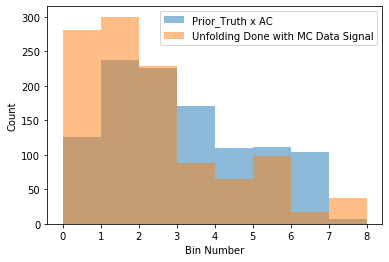

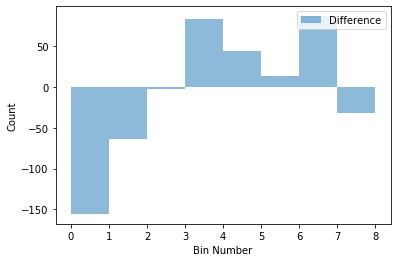

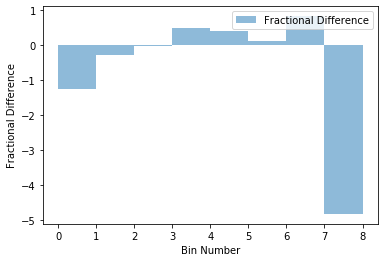

In [56]:
import random
import numpy
from matplotlib import pyplot

bins = np.arange(0, 9, 1)
count = np.arange(0.0, 8.0, 1)

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()

pyplot.hist(count, bins, weights=diff, alpha=0.5, label='Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()


pyplot.hist(count, bins, weights=diffasfrac, alpha=0.5, label='Fractional Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Fractional Difference")
pyplot.show()

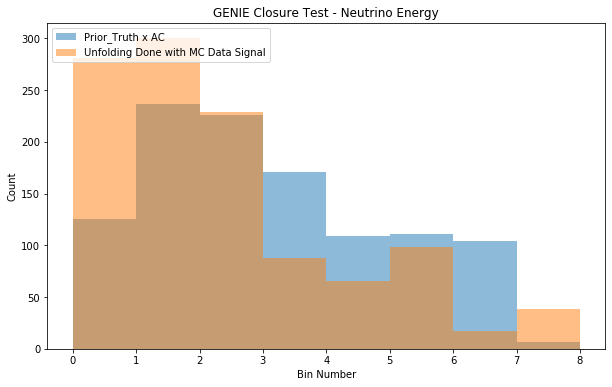

In [57]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper left')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.title("GENIE Closure Test - Neutrino Energy")
pyplot.show()

#fig.savefig("Data_closure_test_lepton_"+ending+".svg",bbox_inches='tight' )

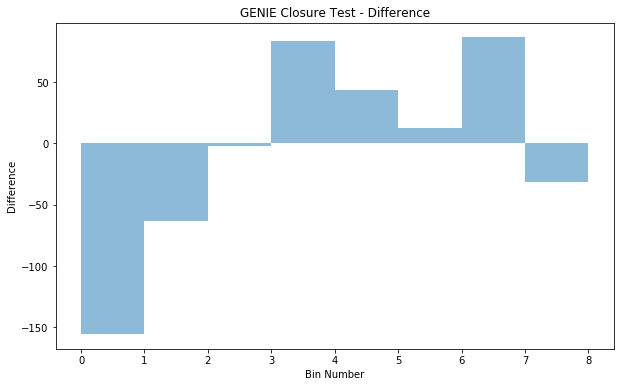

In [58]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=diff, alpha=0.5)
#pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Difference")
pyplot.title("GENIE Closure Test - Difference")
pyplot.show()

#fig.savefig("Data_closure_test_diff_lepton_"+ending+".svg",bbox_inches='tight' )

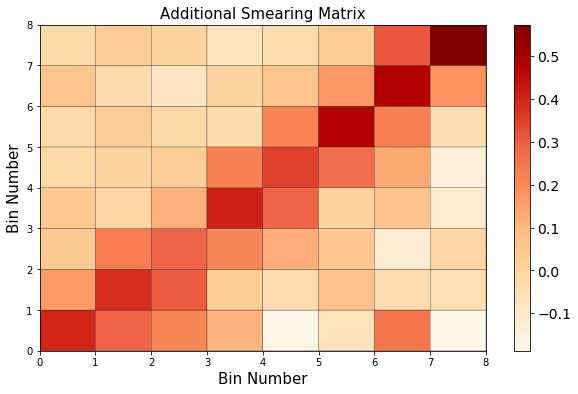

In [59]:
fig = plt.figure(figsize=(10, 6))  
    
plt.pcolor(bins, bins, chunks, cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title('Additional Smearing Matrix', fontsize=15)

plt.show()

#fig.savefig("Data_closure_test_Ac_lepton_"+ending+".svg",bbox_inches='tight' )

/tmp/ipykernel_48917/847473622.py:7: RuntimeWarning: invalid value encountered in log
  plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)


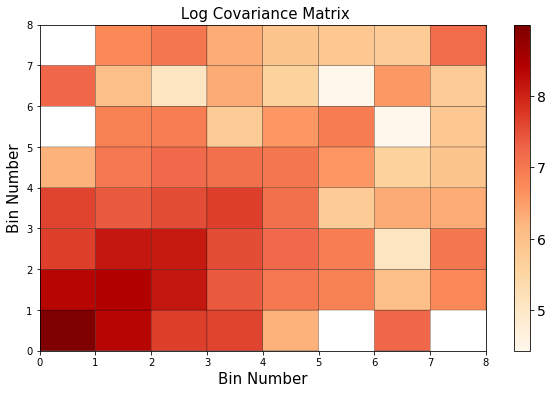

In [60]:
fig = plt.figure(figsize=(10, 6))  

#print(bins)
bins = np.arange(0, 9, 1)
count = np.arange(0.0, 8.0, 1)
    
plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

## Need to convert to xsec units

xsec = unfolded event counts / (integrated flux * number of argon targets)

In [61]:
###################
### #N argon target calculation
###################

density = 1.3836  #g/cm^3
volume = (246-10)*(106-(-106))*(1026-10)         #cm^3
NA = 6.022E23   #atoms/mol
Nnuc = 40       #nucleans / atom
mmol = 39.95    #g/mol

Narg = (density * volume * NA * Nnuc)/mmol   #nucleons

print("number of argon targets = ", Narg)

number of argon targets =  4.240685683288815e+31


In [62]:
#Need R1 AND R3

####NUE
POT_R1 = 2.0E20 
int_flux_per_POT_R1 = 1.1864530596659353e-11
POT_R3 = 5.014E20
int_flux_per_POT_R3 = 8.628376225834778e-12

int_flux = (int_flux_per_POT_R1*POT_R1) + (int_flux_per_POT_R3*POT_R3)    #cm^-2

print("Nue integrated flux: ", int_flux)


Nue integrated flux:  6699173958.965427


In [63]:
nue_events = np.array(events)

nue_errs = np.array(errs)

In [64]:
#effs_nue = [0.04470284782848581 , 0.11462614682695119 , 0.1446477999768762, 0.15782447029421803, \
#        0.12834797911353926, 0.11772709219835302,  0.11949612412227617,  0.0969185691336516]

In [65]:
#number of events

xsec_nue_events = []

#for i in np.arange(len(nue_events)):
#    xsec_nue_events.append(nue_events[i] / (int_flux * Narg * 0.25 * effs_nue[i]))

xsec_nue_events = nue_events / (int_flux * Narg * 0.25) 

print(xsec_nue_events)


#uncertainty

#xsec_nue_errs = nue_errs / (int_flux * Narg )     
#xsec_numu_errs = numu_errs / (int_flux_numu * Narg )     

[3.95267837e-39 4.22826621e-39 3.21739262e-39 1.23605785e-39
 9.21854202e-40 1.38149017e-39 2.45904382e-40 5.35327228e-40]


In [66]:
#Need the four sections of the cov matrix

blockwise_errs = chunks_cov
#print(blockwise_errs)
#print("")

#NUE ONLY
bot_left = blockwise_errs
for i in range(len(bot_left)):
    bot_left[i] = bot_left[i]
    
nue_errs_bot = np.array(bot_left)/((int_flux*int_flux)*(Narg*Narg)*(0.25*0.25))
xsec_nue_errs = (np.sqrt(np.diag(nue_errs_bot)))

In [67]:
print(xsec_nue_events)
print("")
print(xsec_nue_errs)

[3.95267837e-39 4.22826621e-39 3.21739262e-39 1.23605785e-39
 9.21854202e-40 1.38149017e-39 2.45904382e-40 5.35327228e-40]

[1.26383353e-39 9.51416339e-40 8.12930715e-40 6.57054929e-40
 4.71488722e-40 4.56791307e-40 3.76383444e-40 5.11772650e-40]


No handles with labels found to put in legend.


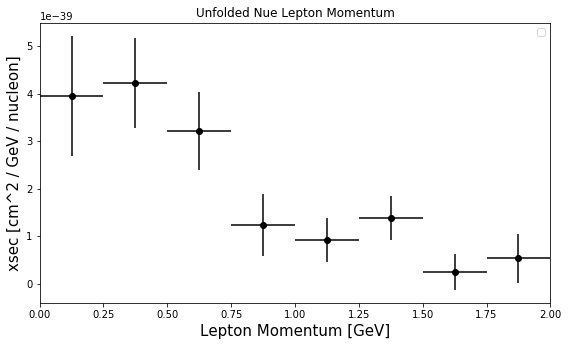

In [68]:
import random
import numpy
from matplotlib import pyplot

nue_fig = plt.figure(figsize=(8, 7))
nue_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_ax1 = plt.subplot(nue_gs[0])

nue_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

nue_ax1.errorbar(
            current_bincenters,
            np.array(xsec_nue_events),
            xerr=current_bin_size/2,
            yerr=xsec_nue_errs,
            fmt='ko')

plt.title("Unfolded Nue Lepton Momentum")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('xsec [cm^2 / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)


#nue_fig.savefig("unfolded_MC_nue_lepton_"+ending+".svg",bbox_inches='tight' )

## Now compare the unfolded result to the GENIE prior truth x Ac

In [69]:
smeared_truth = np.dot(prior_true, chunks)
#smeared_nuWro = np.dot(prior_true_nuWro, nuWro_Ac)
print("Prior_Truth x AC: ")
print(smeared_truth)

Prior_Truth x AC: 
[125.29591411 236.8292472  226.25198656 171.30682662 109.24497664
 110.87917864 103.82007546   6.53986585]


In [70]:
nue_smeared_truth = np.array(smeared_truth)

In [71]:
xsec_nue_smeared_truth = nue_smeared_truth / (int_flux * Narg *0.25) 

In [72]:
bins = np.arange(0, 2.25, 0.25)
count = np.arange(0.125, 2.125, 0.25)

print(bins)
print(count)

[0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.  ]
[0.125 0.375 0.625 0.875 1.125 1.375 1.625 1.875]


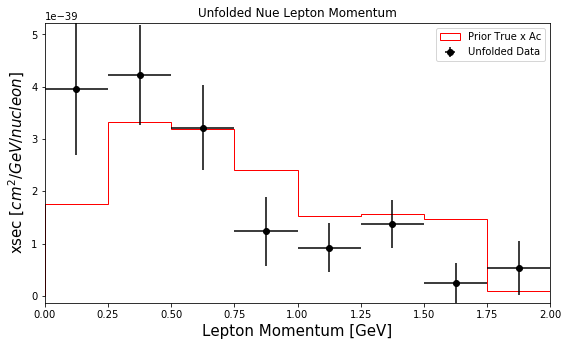

In [73]:
nue_fig = plt.figure(figsize=(8, 7))
nue_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_ax1 = plt.subplot(nue_gs[0])

nue_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

f_obs_nue = nue_ax1.errorbar(
            current_bincenters,
            xsec_nue_events,
            xerr=current_bin_size/2,
            yerr=xsec_nue_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_nue = nue_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_nue_smeared_truth, label='Prior True x Ac', histtype="step")
#nue_ax1.step(count, bins, label='Prior True x Ac')



plt.title("Unfolded Nue Lepton Momentum")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('xsec [$cm^{2} / GeV / nucleon$]', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)

#nue_fig.savefig("unfolded_MC_nue_lepton_comp_"+ending+".svg",bbox_inches='tight' )

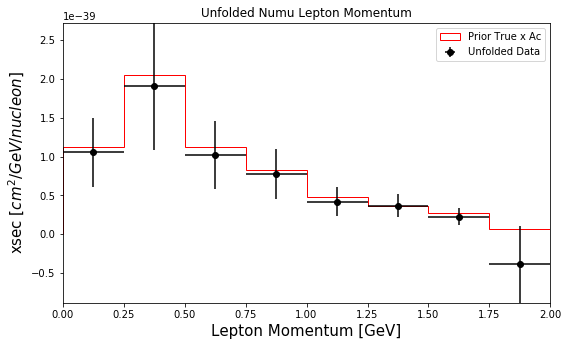

In [283]:
numu_fig = plt.figure(figsize=(8, 7))
numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
numu_ax1 = plt.subplot(numu_gs[0])

numu_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

numu_ax1.errorbar(
            current_bincenters,
            xsec_numu_events,
            xerr=current_bin_size/2,
            yerr=xsec_numu_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_numu = numu_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_numu_smeared_truth, label='Prior True x Ac', histtype="step")
#nue_ax1.step(count, bins, label='Prior True x Ac')



plt.title("Unfolded Numu Lepton Momentum")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('xsec [$cm^{2} / GeV / nucleon$]', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)

numu_fig.savefig("unfolded_MC_numu_lepton_comp_"+ending+".svg",bbox_inches='tight' )

(0, 4)

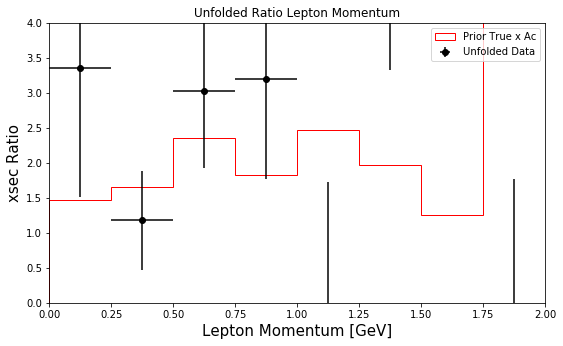

In [284]:
ratio_fig = plt.figure(figsize=(8, 7))
ratio_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
ratio_ax1 = plt.subplot(ratio_gs[0])

ratio_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

ratio_ax1.errorbar(
            current_bincenters,
            xsec_ratio_events,
            xerr=current_bin_size/2,
            yerr=xsec_ratio_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_ratio = ratio_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_ratio_smeared_truth, label='Prior True x Ac', histtype="step")


plt.title("Unfolded Ratio Lepton Momentum")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('xsec Ratio', fontsize=15)
plt.legend()
plt.tight_layout()
plt.ylim(0, 4)

#ratio_fig.savefig("unfolded_MC_ratio_lepton_comp_"+ending+".svg",bbox_inches='tight' )

## Some Chi2 Tests

In [285]:
#NUE

import scipy.stats as sp

f_obs_nue = xsec_nue_events
f_exp_nue = f_exp_nue[0]

print(f_obs_nue)
print(f_exp_nue)

[ 3.53526270e-39  2.25116671e-39  3.09637502e-39  2.48968190e-39
 -2.74859902e-40  2.48978046e-39 -6.75506300e-40  1.85449087e-39]
[1.64272784e-39 3.40145833e-39 2.64208318e-39 1.52535325e-39
 1.18385499e-39 7.16001445e-40 3.42738986e-40 1.26706221e-39]


In [286]:
inverse_unfcov_nue = np.linalg.inv(nue_errs_bot)

In [287]:
chi2_genie_nue = 0

print(len(bins)-1)
print(len(f_obs_nue))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_nue)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_nue = chi2_genie_nue  + ( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov_nue[i][j]*(f_obs_nue[j]-f_exp_nue[j]) )

8
8


In [288]:
chi2_genie_nue

12.515842341490497

In [289]:
#NUMU

f_obs_numu = xsec_numu_events
f_exp_numu = f_exp_numu[0]

print(f_obs_numu)
print(f_exp_numu)

[ 1.05391267e-39  1.90455532e-39  1.02068884e-39  7.76916618e-40
  4.21022809e-40  3.67102429e-40  2.24026718e-40 -3.89683699e-40]
[1.12027761e-39 2.05535864e-39 1.12342276e-39 8.33624213e-40
 4.79806129e-40 3.62979220e-40 2.74547844e-40 7.10003185e-41]


In [290]:
inverse_unfcov_numu = np.linalg.inv(numu_errs_top)
#inverse_unfcov_numu = np.linalg.inv(test_cov_errs)

In [291]:
chi2_genie_numu = 0

print(len(bins)-1)
print(len(f_obs_numu))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_numu)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_numu = chi2_genie_numu  + ( (f_obs_numu[i]-f_exp_numu[i])*inverse_unfcov_numu[i][j]*(f_obs_numu[j]-f_exp_numu[j]) )

8
8


In [292]:
chi2_genie_numu

2.080767987130457

In [293]:
#RATIO

f_obs_ratio = xsec_ratio_events
f_exp_ratio = f_exp_ratio[0]

print(f_obs_ratio)
print(f_exp_ratio)

[ 3.35441711  1.18199072  3.03361308  3.20456771 -0.65283851  6.78225004
 -3.01529347 -4.75896444]
[ 1.46635783  1.65492204  2.3518156   1.8297852   2.46736111  1.97256869
  1.24837617 17.84586662]


In [294]:
bins = np.arange(0, 2.25, 0.25)
#ratio_cov_errs    = np.zeros([len(bins)-1, len(bins)-1])

#ratio_cov_errs [np.diag_indices_from(ratio_cov_errs )]     = xsec_ratio_errs*xsec_ratio_errs

nue_term = (nue_errs_bot)/(xsec_nue_events*xsec_nue_events)
#print("nue: ", nue_term)
#print("")
numu_term = (numu_errs_top)/(xsec_numu_events*xsec_numu_events)
#print("numu: ", numu_term)
#print("")
mix_1 = (mix_errs_bot)/(xsec_numu_events*xsec_nue_events)
#print("mix: ", mix_1)
#print("")
mix_2 = (mix_errs_top)/(xsec_numu_events*xsec_nue_events)
#print("mix: ", mix_2)
#print("")

ratio_var_errs = ratio_sq*(nue_term + numu_term - mix_1 - mix_2)
print(ratio_var_errs)
print(np.sqrt(np.diag(ratio_var_errs)))

[[ 3.39743370e+00  1.92555320e-02  4.10906535e-01  2.59691250e+00
  -1.44221489e+00  1.84643211e+01  1.57343342e+01  3.23922355e+00]
 [ 1.27457343e+00  4.98510853e-01  1.16124902e+00  1.06466513e+00
   9.14655185e+00  2.14376453e+01  3.61898795e+01  2.59968778e+00]
 [ 5.70425920e-01  5.39745510e-02  1.21426541e+00  1.55176480e+00
   1.53462297e+00  1.73055725e+01  1.13120917e+01  1.01451553e+01]
 [ 1.48408841e+00 -9.32638050e-02  8.22431195e-01  2.05113437e+00
  -1.77207814e+00  1.58739203e+01  6.64389400e+00  6.30825897e+00]
 [-5.81734567e-01  2.79690462e-01 -7.39762492e-02 -9.13731901e-01
   5.69427096e+00 -2.55721468e+00  1.37370496e+01 -1.71308578e+00]
 [ 7.87333623e-01 -1.68766413e-01  7.24368909e-01  1.52955555e+00
  -3.31715998e+00  1.19599168e+01 -3.90195186e+00  7.56370108e+00]
 [ 1.00493266e-01  1.23035133e-01 -7.41430686e-02 -2.19780607e-01
   2.45143405e+00 -1.08514503e-01  8.42673557e+00 -1.72125611e+00]
 [-4.18921916e-01 -1.31674019e-02 -1.04840619e-01 -4.11286192e-01
  -

In [295]:
inverse_unfcov_ratio = np.linalg.inv(ratio_var_errs)

In [296]:
chi2_genie_ratio = 0

print(len(bins)-1)
print(len(f_obs_ratio))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_ratio)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_ratio = chi2_genie_ratio  + ( (f_obs_ratio[i]-f_exp_ratio[i])*inverse_unfcov_ratio[i][j]*(f_obs_ratio[j]-f_exp_ratio[j]) )

8
8


In [297]:
chi2_genie_ratio

-32.54082586838596